<a href="https://colab.research.google.com/github/jimenami/master_ciencia_datos/blob/main/DATA_MINING/DM2025_Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

En esta sesión vamos a realizaer ejercicios de clasificación con el clásico dataset del titanic. En concreto, practicaremos con los siguientes algoritmos:
*  SVC
*  LogisticRegression
*  DecisionTrees

Para realizar todos los ejercicios, mantén la misma semilla a la hora de realizar los Folds del CrossValidation para comparar los resultados.

También debes responder a unas preguntas relacionadas con la comprensión del temario.


In [3]:
import io
import pandas as pd
from google.colab import files
import numpy as np

# LogisticRegression -> https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# SVC -> https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# DecissionTree ->https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# Kfold -> https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

In [5]:
# La primera tarea será cargar el dataset del Titanic y lo guardamos en un df para poder operar con él
uploaded = files.upload()

Saving TitanicEjemplo.csv to TitanicEjemplo.csv


Una vez el archivo ha sido cargado, permanece en la nube (hasta ser expulsado por inactividad) y es accesible por los métodos de python:

Si haces click en "Archivos": 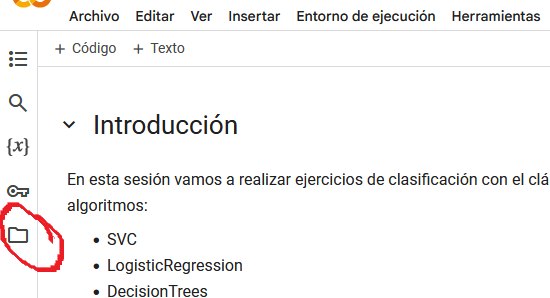

Podrás ver el nuevo archivo que has subido, listo para acceder a él:


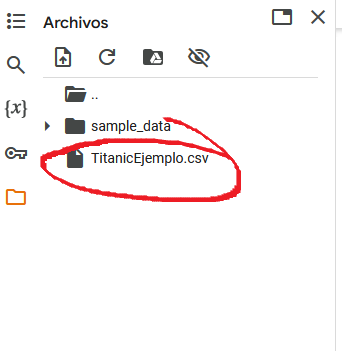

In [6]:
# Por lo que ahora ya puede ser guardado en un dataframe:
df_titanic = pd.read_csv(io.BytesIO(uploaded['TitanicEjemplo.csv']), sep=";")

In [ ]:
# Descripción de los datos
# survival	    Survival	            0 = No, 1 = Yes
# pclass	      Ticket class	        1 = 1st, 2 = 2nd, 3 = 3rd
# sex	          Sex
# Age	          Age in years
# sibsp         # of siblings / spouses aboard the Titanic
# parch	        # of parents / children aboard the Titanic
# ticket	      Ticket number
# fare	        Passenger fare
# cabin	        Cabin number
# embarked	    Port of Embarkation	  C = Cherbourg, Q = Queenstown, S = Southampton



1.   **Dale un vistazo a los datos. ¿Consideras que se podrían eliminar algunas columnas? ¿Por qué?**
2.   **¿Consideras que se podrían eliminar algunas filas? ¿Por qué?**



In [8]:
# Tamaño del dataset
np.shape(df_titanic)

(891, 12)

In [4]:
print(df_titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


La columna del nombre no nos da mucha información, ya que tenemos otra columna que nos indica si los pasajeros son hombres/mujeres y que, por tanto, es más útil a la hora de hacer problemas de clasificación.

La columna del número del billete tampoco nos aporta nada, y el id del pasajero solo nos sirve como clave principal para identificarlos en nuestra base de datos, pero no es útil a nivel machine learning.

Por otro lado, las columnas de sisbp y parch podríamos agruparlas en una sola que nos indicase el nº de parientes a bordo del titanic, independientemente de que sean padres o hermanos, porque esa distinción tampoco nos aporta demasiada información.

La columna del código de la cabina tampoco parece que vaya a aportar mucha información por sí sola aunque sí que puede que sea útil para hacer análisis clúster por ejemplo que agrupe a los individuos y que posteriormente nos pueda servir para estudiar si individuos con cabinas más próximas o alejadas eran más propensos a sobrevivir o fallecer.


Aunque, cabe mencionar que, en general, las columnas a eliminar o transformar dependerán del problema que nos interese realizar.

En cuanto a las filas, podríamos eliminar aquellas con valores vacíos, aunque algunos puntuales podríamos imputarlos.

In [10]:
# Eliminamos las filas que tienen todas las columnas vacías y las filas dupllicadas
df_titanic.drop_duplicates(inplace=True)
df_titanic.dropna(how='all', inplace=True)
np.shape(df_titanic)


(891, 12)

## Ejercicio 1: Algoritmo SVC

1. Prepara los datos y realiza un modelo de clasificación basado en SVC, con el
escalador MinMax. Cross-valida los resultados para un kfold=5. Prueba distintos kernels (rbf, linear y poly) y compara los resultados.
1.   Realiza un modelo de clasificación basado en SVC, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5. Prueba distintos kernels (rbf, linear y poly) y compara los resultados.

Tras realizar las operaciones de preprocesado de datos para el algoritmos SVC, deberíaas de haber obtenido un dataset similar a este:

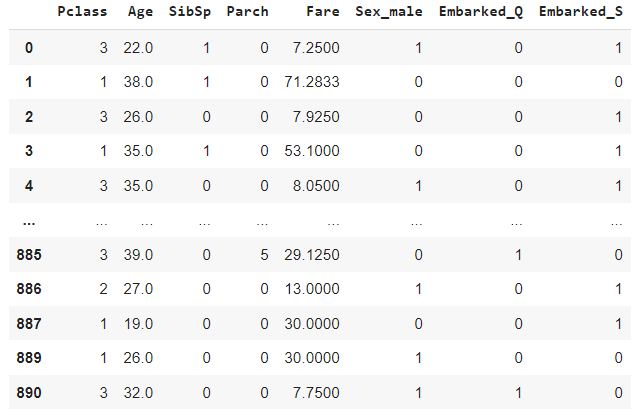


3.   **En dicho dataset, se ha realizado una operación de one-hot-encoding sobre la variable de Embarked, pero no sobre la de Pclass (que realmente también corresponden a etiquetas discretas, que van de 1 a 3). ¿Por qué? ¿Por qué no podríamos haber sustituido las etiquestas de Q,S,C por los números 1,2,3 y dejarlo como la columna Pclass?**
4.   **Además, por qué Embarked tiene únicamente 2 columnas, cuando tal como se puede ver en la descripción de los datos, podría tener 3 valores de etiqueta (Q, S, C)?**

### **SVC**
Para realizar el SVC necesito trabajar con variables binarias o numéricas.
Por ello voy a eliminar las columnas de nombre, cabina, número de ticket e id del pasajero.

La variable binaria sexo la voy a transofrmar dando los valores 0 para el hombre y 1 para la mujer.
Y a la variable Embarked le vamos a hacer un "one-hot-encoding" de forma que cada categoría se convierta en una categoría.



In [7]:
df_titanic = df_titanic.drop(columns = ['Name','Cabin', 'PassengerId','Ticket'])
# Convertimos Sex a variable binaria de 0 y 1
df_titanic['Sex'] = (df_titanic['Sex'] == 'male').astype(int)

# Hacemos one-hot-encoding a la columna Embarked
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'])

# Podemos eliminar una de las 3 columnas creadas, por ejemplo Embarked_C como nos indican arriba, porque si un pasajero no embarcó ni en S ni en Q entonces por narices
# embarcó en C, son excluyentes; es decir, que solo 2 columnas ya contienen toda la información de las 3.
df_titanic = df_titanic.drop(columns = ['Embarked_C'])

# Ponemos False = 0 y True = 1 en las otras 2
df_titanic['Embarked_S'] = (df_titanic['Embarked_S'] == True).astype(int)
df_titanic['Embarked_Q'] = (df_titanic['Embarked_Q'] == True).astype(int)

# Por último, eliminamos los valores faltantes NaN, que el SVC no va a poder trabajar con ellos
df_titanic = df_titanic.dropna()
df_titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,1,0
886,0,2,1,27.0,0,0,13.0000,0,1
887,1,1,0,19.0,0,0,30.0000,0,1
889,1,1,1,26.0,0,0,30.0000,0,0


Primero vamos a probar el **escalador MinMax** con distintos kernels.

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold, cross_validate

# La variable objetivo es 'Survived' y el resto son las variables predictoras que vamos a usar
X = df_titanic.drop(columns = ['Survived'])
y = df_titanic['Survived']

# Hacemos la división del dataset en 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

# Instantiate the scaler before using it
scaler = MinMaxScaler()

# Aprendemos de Train y escalamos Train
X_train_scaled = scaler.fit_transform(X_train)

# Escalamos Test usando SOLO lo aprendido de Train. Por eso usamos transform en lugar de fit_transform, para evitar data leakage
X_test_scaled = scaler.transform(X_test)

In [63]:
# Vamos a hacer la cross-validation para los distintos kernels en el conjunto de train.
# Ponemos la semilla en 43 para garantizar reproducibilidad de los resultados
cv = KFold(n_splits=5, shuffle=True, random_state=43)

kernels = ['linear', 'poly', 'rbf']
resultados = {}

for kernel in kernels:
  modelo = SVC(kernel=kernel)
  # Realizamos la validación cruzada
  scores = cross_val_score(modelo, X_train.scaled, y_train, cv=cv, scoring='accuracy')
  resultados[kernel] = scores.mean()
  print(f"Kernel {kernel:7}:Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")


Kernel linear :Accuracy media con regla std= 0.7758 (+/- 0.0209)
Kernel poly   :Accuracy media con regla std= 0.7968 (+/- 0.0174)
Kernel rbf    :Accuracy media con regla std= 0.8038 (+/- 0.0265)


In [64]:
# El mejor resultado nos sale para el kernel radial
# Lo aplicamos a los datos de test para ver cómo funciona en ellos

modelo = SVC(kernel='rbf')
modelo.fit(X_train_scaled, y_train)
modelo.score(X_test_scaled, y_test)

0.7832167832167832

Obviamente es normal que la accuracy disminuya un poco en los datos de test.

Ahora vamos a usar el escalador **RobustScaler** y ver si cambian los resultados

In [65]:
from sklearn.preprocessing import RobustScaler

# La división train-test queremos que sea la misma así que no la tocamos
# Escalamos ahora con el nuevo escalador
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=43)
resultados2 = {}

kernels = ['linear','poly','rbf']
for kernel in kernels:
  modelo = SVC(kernel=kernel)
  scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='accuracy')
  resultados2[kernel] = scores.mean()
  print(f"Kernel {kernel:7}:Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")


Kernel linear :Accuracy media con regla std= 0.7758 (+/- 0.0209)
Kernel poly   :Accuracy media con regla std= 0.7461 (+/- 0.0254)
Kernel rbf    :Accuracy media con regla std= 0.8126 (+/- 0.0132)


In [66]:
# Los resultados ahora son peores con los kernels lineal y polinómico, pero mejoran ligeramente con el radial.
# Lo aplicamos a los datos de test para ver cómo generaliza

modelo = SVC(kernel='rbf')
modelo.fit(X_train_scaled, y_train)
modelo.score(X_test_scaled, y_test)

0.8041958041958042

### preguntas de los apartados 3 y 4.

En primer lugar, no podríamos haber sustituido las etiquestas de Q,S,C por los números 1,2,3 y dejarlo como la columna Pclass porque esa numeración implica un orden y una agrupación. La primera clase es más importante que la segunda y que la tercera. Pero esto no tiene sentido para los puertos de embarcación.

Como se trata de un problema de clasificación, el algoritmo puede coger y agrupar las clases 2 y 3 en una sola separadas de la clase 1 de forma que todo lo que sea > 1 va a esa agrupación y todo lo que sea < 1 va a la clase 1, pero esto no tendría sentido para los puertos.

Por otra parte, basta que Embarked sea representado con 2 columnas porque si los valores son 0 en las 2 entonces es porque el pasajero embarcó en el puerto que no está presente (en nuestro caso es el C), mientras que si hay un 1 en cualquiera de esas 2 columnas es porque el pasajero embarcó en ese puerto.
Con 2 columnas nos basta para transmitir toda la información contenida y esto nos ahorra procesamiento.


## Ejercicio 2: Algoritmo LogisticRegression

1.   Realiza un modelo de clasificación basado en LinearRegression, con el escalador MinMax. Cross-valida los resultados para un kfold=5. Obtén los coeficientes de las variables de cualquier iteración.
2.   Realiza un modelo de clasificación basado en LinearRegression, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5. Obtén los coeficientes de las variables de cualquier iteración.





Escalador **MinMaxScaler**

In [95]:
from sklearn.linear_model import LogisticRegression
# Los datos de train y test no hace falta que los toquemos

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=43)
# Instanciamos el modelo
modelo = LogisticRegression(max_iter=1000)

# Ejecutamos la validación cruzada guardando los modelos para poder printear los coeficientes
resultados_cv = cross_validate(modelo, X_train_scaled, y_train, cv=cv, scoring='accuracy', return_estimator=True)
scores = resultados_cv['test_score']
print(f"Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")

# Printeamos los coeficientes de las variables de cada iteración
for i, estimador in enumerate(resultados_cv['estimator']):
    df_coefs = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': estimador.coef_[0]
    }).sort_values(by='Coeficiente', ascending=False)

    print(f"--- Coeficientes del Fold {i+1} ---")
    print(df_coefs)
    print("-" * 30)
    print(f"Accuracy del Fold {i+1}")
    print(estimador.score(X_train_scaled, y_train))

Accuracy media con regla std= 0.7776 (+/- 0.0175)
--- Coeficientes del Fold 1 ---
     Variable  Coeficiente
5        Fare     0.530432
4       Parch    -0.241212
7  Embarked_S    -0.714262
6  Embarked_Q    -0.727186
3       SibSp    -1.005901
2         Age    -1.768474
0      Pclass    -1.891290
1         Sex    -2.323597
------------------------------
Accuracy del Fold 1
0.7915936952714536
--- Coeficientes del Fold 2 ---
     Variable  Coeficiente
5        Fare     0.635381
4       Parch     0.024178
6  Embarked_Q    -0.344051
7  Embarked_S    -0.369159
3       SibSp    -0.959685
2         Age    -1.396046
0      Pclass    -1.898112
1         Sex    -2.308977
------------------------------
Accuracy del Fold 2
0.7898423817863398
--- Coeficientes del Fold 3 ---
     Variable  Coeficiente
5        Fare     0.684775
6  Embarked_Q     0.026153
4       Parch    -0.212199
7  Embarked_S    -0.236883
3       SibSp    -1.092445
0      Pclass    -1.854949
2         Age    -2.205722
1         Se

Escalador **RobustScaler**

In [108]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=43)
# Instanciamos el modelo
modelo = LogisticRegression(max_iter=1000)

# Ejecutamos la validación cruzada guardando los modelos para poder printear los coeficientes
resultados_cv2 = cross_validate(modelo, X_train_scaled, y_train, cv=cv, scoring='accuracy', return_estimator=True)
scores = resultados_cv2['test_score']
print(f"Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")

# Printeamos los coeficientes de las variables de cada iteración
for i, estimador in enumerate(resultados_cv2['estimator']):
    df_coefs = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': estimador.coef_[0]
    }).sort_values(by='Coeficiente', ascending=False)

    print(f"--- Coeficientes del Fold {i+1} ---")
    print(df_coefs)
    print("-" * 30)
    print(f"Accuracy del Fold {i+1}")
    print(estimador.score(X_train_scaled, y_train))

Accuracy media con regla std= 0.7776 (+/- 0.0133)
--- Coeficientes del Fold 1 ---
     Variable  Coeficiente
5        Fare     0.062590
4       Parch    -0.049319
3       SibSp    -0.363862
7  Embarked_S    -0.637048
2         Age    -0.673404
6  Embarked_Q    -0.716456
0      Pclass    -1.070404
1         Sex    -2.369010
------------------------------
Accuracy del Fold 1
0.7933450087565674
--- Coeficientes del Fold 2 ---
     Variable  Coeficiente
5        Fare     0.096355
4       Parch     0.016406
7  Embarked_S    -0.257664
6  Embarked_Q    -0.269253
3       SibSp    -0.343101
2         Age    -0.541139
0      Pclass    -1.036508
1         Sex    -2.332036
------------------------------
Accuracy del Fold 2
0.7950963222416813
--- Coeficientes del Fold 3 ---
     Variable  Coeficiente
6  Embarked_Q     0.117876
5        Fare     0.090721
4       Parch    -0.051607
7  Embarked_S    -0.119711
3       SibSp    -0.409416
2         Age    -0.844354
0      Pclass    -1.066589
1         Se

Nos sale la misma accuracy media que con el escalador anterior, aunque ahora la desviación típica es un poco menor.




5.   **¿Qué información/explicabilidad se puede extraer de los modelos?¿Como interpretas los resultados?**



Los resultados son interpretables prácticamente de la misma manera para ambos escaladores.
Los modelos identifican que la variable más influyente en la supervivencia es el sexo, cuyo coeficiente es el más alto en valor absoluto, seguido por orden de la clase y la edad.
Lo cual tiene sentido pues sabemos que en el titanic las personas que más sobrevivieron fueron las mujeres y los niños, además de la gente de muy alta clase social.

Para interpretar cómo de bien son los modelos clasificando hemos estado usando el accuracy, pero podríamos observar otras métricas.

## Ejercicio 3: DecisionTree (1/2)

1.   Realiza un modelo de clasificación basado en DecisionTree, con el escalador MinMax. Cross-valida los resultados para un kfold=5.
1.   Realiza un modelo de clasificación basado en DecisionTree, con el escalador RobustScaler. Cross-valida los resultados para un kfold=5.
1.   Realiza un modelo de clasificación basado en DecisionTree, sin escalador. Cross-valida los resultados para un kfold=5.

Escalador **MinMaxScaler**

In [121]:
from sklearn import tree

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=43)
decision_tree = tree.DecisionTreeClassifier()
resultados_cv3 = cross_validate(decision_tree, X_train_scaled, y_train, cv=cv, scoring='accuracy', return_estimator=True)
scores = resultados_cv3['test_score']
print(f"Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")


Accuracy media con regla std= 0.7460 (+/- 0.0291)


In [122]:
# Nos sale la peor accuracy que el resto de modelos usados hasta ahora.
# Veámos cómo generaliza

decision_tree = tree.DecisionTreeClassifier()
decision_tree.fit(X_train_scaled, y_train)
decision_tree.score(X_test_scaled, y_test)

0.7622377622377622

Sorprendentemente generaliza mejor con los datos que no ha visto antes, esto es bastante raro que pase pero no imposible.
Para el árbol de decisión, en lugar de los coeficientes, podemos ver la importancia de Gini de las variables.

In [123]:
# Extraemos la importancia media de los 5 modelos del CV
importancias = np.mean([est.feature_importances_ for est in resultados_cv3['estimator']], axis=0)

df_imp = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nImportancia de las variables en el Árbol:")
print(df_imp)


Importancia de las variables en el Árbol:
     Variable  Importancia
1         Sex     0.281510
2         Age     0.247384
5        Fare     0.235989
0      Pclass     0.122191
3       SibSp     0.060619
4       Parch     0.029268
7  Embarked_S     0.018354
6  Embarked_Q     0.004685


Para el árbol de decisión las variables más importantes son: Sexo, Edad y Fare (en lugar de Edad como la regresión logística)

Escalador **RobustScaler**

In [124]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=43)
decision_tree = tree.DecisionTreeClassifier()
resultados_cv4 = cross_validate(decision_tree, X_train_scaled, y_train, cv=cv, scoring='accuracy', return_estimator=True)
scores = resultados_cv4['test_score']
print(f"Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy media con regla std= 0.7496 (+/- 0.0275)


La accuracy es un pelín mejor que con el otro escalador pero sigue siendo mucho peor que para el resto de modelos que hemos usado.
Veámos cómo generaliza


In [126]:
tree = tree.DecisionTreeClassifier()
tree.fit(X_train_scaled, y_train)
tree.score(X_test_scaled, y_test)

0.7552447552447552

Generaliza peor que usando el escalador. Aunque de nuevo la accuracy para test sale más alta que para train.
Veámos si la importancia que le da a las variables es igual que para el otro.

In [127]:
importancias = np.mean([est.feature_importances_ for est in resultados_cv4['estimator']], axis=0)

df_imp = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nImportancia de las variables en el Árbol:")
print(df_imp)


Importancia de las variables en el Árbol:
     Variable  Importancia
1         Sex     0.281510
2         Age     0.244830
5        Fare     0.237365
0      Pclass     0.126493
3       SibSp     0.055775
4       Parch     0.029666
7  Embarked_S     0.016925
6  Embarked_Q     0.007436


En efecto, siguen siendo Sexo, Edad y Precio las más importantes.
Y con unas importancias bastante parecidas. Solo cambian los decimales.

Por último vamos a aplicar el árbol de decisión **sin haber escalado previamente las variables predictoras**

In [135]:
from sklearn import tree

In [133]:
tree = tree.DecisionTreeClassifier()
cv = KFold(n_splits=5, shuffle=True, random_state=43)
resultados_cv5 = cross_validate(tree, X_train, y_train, cv=cv, scoring='accuracy', return_estimator=True)
scores = resultados_cv5['test_score']
print(f"Accuracy media con regla std= {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy media con regla std= 0.7461 (+/- 0.0248)


Igualmente, la accuracy es más baja que usando el escalador RobustScaler. Veámos cómo generaliza el modelo.

In [136]:
tree = tree.DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree.score(X_test, y_test)

0.7762237762237763

Es el que mejor generaliza hasta ahora. Veámos su importancia de Gini

---



In [137]:
importancias = np.mean([est.feature_importances_ for est in resultados_cv5['estimator']], axis=0)

df_imp = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nImportancia de las variables en el Árbol:")
print(df_imp)


Importancia de las variables en el Árbol:
     Variable  Importancia
1         Sex     0.281510
2         Age     0.243751
5        Fare     0.234700
0      Pclass     0.128254
3       SibSp     0.060035
4       Parch     0.029299
7  Embarked_S     0.017413
6  Embarked_Q     0.005038


**6. Compara los 3 resultados de los tres algoritmos de DecisionTree? ¿Qué ocurre? ¿Por qué está pasando eso?**

El árbol sin escalado es el que mejor generaliza porque aunque para el algoritmo es lo mismo, el ruido numérico del escalado a veces introduce pequeñas variaciones en la búsqueda del "mejor punto de corte".


## Ejercicio 4: DecisionTree (2/2)

1.   Construye dos modelos de clasificación basados en DecisionTree (sin escalador). Calcula el número de hojas y de niveles del árbol. A continuación poda el árbol a 5 niveles y compara los resultados con el árbol completo.

Tienes un trozo de código que te ayudará a dibujar el árbol, y te aparecerá un archivo en PDF en el directorio del COLAB que podrás descargar para visualizar.

In [9]:
from sklearn import tree
arbol = tree.DecisionTreeClassifier()

# Lo vamos a entrenar con todos los datos, sin hacer división de train-test
arbol.fit(X, y)
arbol.score(X,y)

0.9859943977591037

Si nos fijamos, al entrenarlo con todos los datos, la accuracy ha mejorado muchísimo.

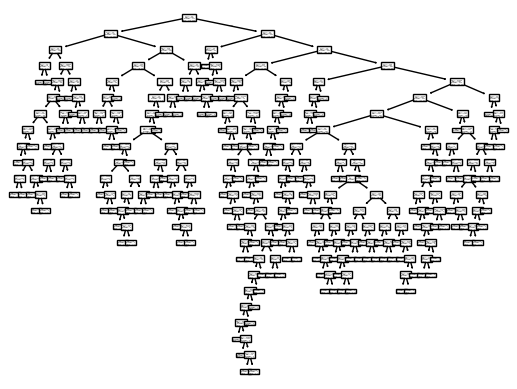

In [12]:
# Para dibujar el árbol
from sklearn import tree
# Para guardar el árbol con una resolución que se pueda ver
import matplotlib.pyplot as plt

# "model" la variable que tiene el modelo de ML que quieres dibujar

tree.plot_tree(arbol)
plt.savefig('arbol_sin_podar.pdf')

In [148]:
# Calculamos el nº de niveles y de hojas
niveles = arbol.get_depth()
hojas = arbol.get_n_leaves()
print("Hojas:", hojas)
print("Niveles:", niveles)

Hojas: 169
Niveles: 20


A continuación, vamos a podar el árbol a 5 niveles

In [10]:
from sklearn import tree
arbol2 = tree.DecisionTreeClassifier(max_depth=5)
arbol2.fit(X_train, y_train)
arbol2.score(X_test, y_test)

0.7902097902097902

Su accuracy es menor, pero esto evita el overfitting. Veámos cuántas hojas tiene ahora y grafiquémoslo.

In [150]:
hojas = arbol2.get_n_leaves()
print("Hojas:", hojas)

Hojas: 26


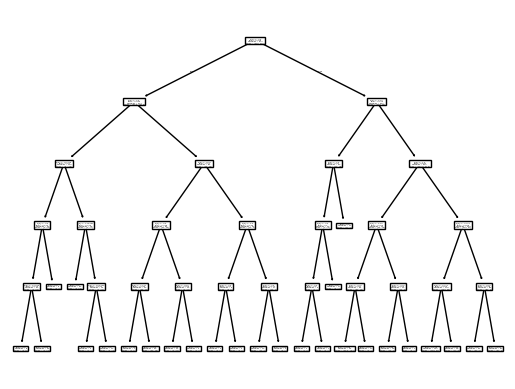

In [151]:
from sklearn import tree
# Para guardar el árbol con una resolución que se pueda ver
import matplotlib.pyplot as plt

# "model" la variable que tiene el modelo de ML que quieres dibujar

tree.plot_tree(arbol2)
plt.savefig('arbol_podado.pdf')

**7.   ¿A qué dimensiones se le da más importancia?¿Coinciden con las dimensiones de LogisticRegression?**

In [11]:
# Calculamos la importancia de Gini de arbol y arbol2

importancias1 =arbol.feature_importances_
importancias2 = arbol2.feature_importances_

df_importancia1 = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias1
})
df_importancia2 = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias2
})

df_importancia1 = df_importancia1.sort_values(by='Importancia', ascending=False)
df_importancia2 = df_importancia2.sort_values(by='Importancia', ascending = False)

print("Importancias del árbol sin podar:")
print(df_importancia1)

print("Importancias del árbol podado:")
print(df_importancia2)

Importancias del árbol sin podar:
     Variable  Importancia
1         Sex     0.299612
2         Age     0.258978
5        Fare     0.204047
0      Pclass     0.132814
3       SibSp     0.058061
4       Parch     0.026567
7  Embarked_S     0.018723
6  Embarked_Q     0.001198
Importancias del árbol podado:
     Variable  Importancia
1         Sex     0.463774
0      Pclass     0.209617
2         Age     0.169965
3       SibSp     0.077027
5        Fare     0.057875
4       Parch     0.021742
6  Embarked_Q     0.000000
7  Embarked_S     0.000000


El árbol sin podar da las mayores importancias a sexo, edad y precio, mientras que el árbol podado da las mayores importancias a sexo, clase y edad.

Además, aunque sexo sea la primera para ambos, la importancia que le da el árbol podado es mucho mayor, de 0.46378 vs 0.2996 del árbol sin podar.

**8.   Dale un vistazo a las últimas hojas del árbol sin límite¿Tienen alguna importancia?¿Aportan información relevante al modelo de ML?**

Si nos fijamos, en las últimas hojas aparecen 1,2 o como mucho 3 pasajeros. El árbol está sobreajustadísimo.

Además, en esas hojas la importancia de Gini es 0.0, esas divisiones no aportan nada literalmente.
Y es imposible de interpretar.
